In [1]:
print("hello")

hello


In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("abbas829/healthcare-patient-analytics-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(path + "/" + os.listdir(path)[0])
df.head()


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 90.6k/90.6k [00:00<00:00, 312kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\abbas829\healthcare-patient-analytics-dataset\versions\1


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


In [3]:
df.describe()

,patient_id,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,4.059660,54915.471800,74.718800,0.280966
std,1443.520003,1.928847,19481.160487,11.870481,0.157178
min,1.000000,0.000000,746.000000,33.000000,0.010000
25%,1250.750000,2.700000,41244.750000,67.000000,0.160000
50%,2500.500000,4.000000,55123.500000,75.000000,0.260000
75%,3750.250000,5.400000,68012.000000,83.000000,0.380000
max,5000.000000,11.900000,119307.000000,100.000000,0.840000


Summary : 

Columns description:
patient_id : 
visit_date : 

Mistakes: 
1. null values present in department column


In [7]:
# df[df['length_of_stay_days'] <= 11]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
 10  recovery_score       5000 non-null   float64
 11  readmission_risk     5000 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 468.9+ KB


In [9]:
df.isnull().sum()

patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
recovery_score         0
readmission_risk       0
dtype: int64

In [11]:
df.sample(20)

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
1043,1044,2022-02-13 11:00:00,46-60,Male,West,General Medicine,Medication,Routine,5.6,71613.0,83.0,0.35
301,302,2022-01-13 13:00:00,31-45,Male,South,Pediatrics,Observation,Routine,5.3,56889.0,60.0,0.06
3751,3752,2022-06-06 07:00:00,60+,Female,West,Orthopedics,Therapy,Routine,0.5,30574.0,100.0,0.18
2043,2044,2022-03-27 03:00:00,18-30,Female,East,Cardiology,Medication,Routine,4.0,59201.0,73.0,0.72
2514,2515,2022-04-15 18:00:00,46-60,Male,West,Neurology,Medication,Routine,6.4,70215.0,82.0,0.30
4649,4650,2022-07-13 17:00:00,18-30,Male,North,General Medicine,Observation,Routine,3.1,59571.0,83.0,0.13
1258,1259,2022-02-22 10:00:00,18-30,Male,East,Cardiology,Observation,Emergency,5.6,94427.0,56.0,0.38
2579,2580,2022-04-18 11:00:00,46-60,Male,South,Cardiology,Medication,Routine,3.4,33042.0,59.0,0.21
4593,4594,2022-07-11 09:00:00,31-45,Male,West,Pediatrics,Observation,Routine,5.5,95371.0,72.0,0.45
537,538,2022-01-23 09:00:00,18-30,Male,North,General Medicine,Therapy,Emergency,1.8,41008.0,54.0,0.31


In [15]:
# number of patients visit for Neurology

print(f"Number of patient for Nuero department are : {df[df['department'] == 'Neurology'].shape[0]}")

Number of patient for Nuero department are : 967


<Axes: xlabel='department'>

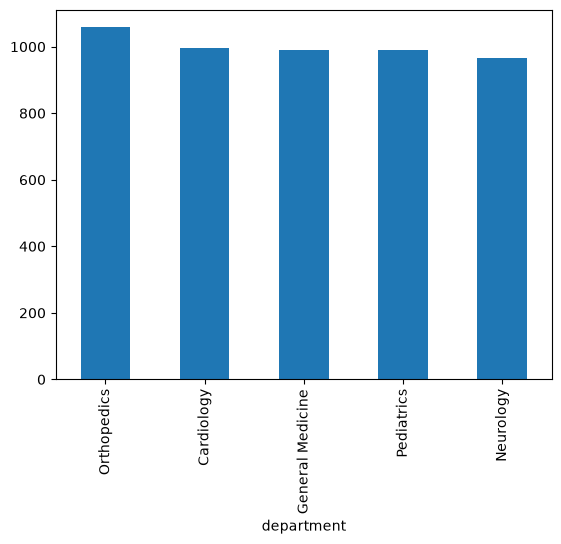

In [16]:
df['department'].value_counts().plot(kind = 'bar')